<a href="https://colab.research.google.com/github/Manoel-Moreira/Analise-de-Sentimento-com-Machine-Learning/blob/main/Projeto_Analise_Sentimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>

# <font color='blue'>Modelo de Classificação Para Análise de Sentimentos</font>

## 1. Definição do Problema de Negócio



###
É a fundação do projeto. Nesta etapa, traduzimos uma necessidade da empresa em um objetivo claro para a Ciência de Dados. Definimos o que queremos resolver (automatizar a classificação de reviews de produtos, por exemplo), por que é importante (reduzir custos, agilizar a tomada de decisão) e como o sucesso será medido.

**Definição:**

Uma empresa de e-commerce deseja automatizar a análise de feedback de seus clientes. Atualmente, a análise é feita manualmente, o que é um processo lento, caro e que não escala com o volume de reviews recebidos diariamente.

**Objetivo:**

Criar um modelo de Machine Learning que classifique automaticamente os reviews de produtos como **'positivo'** ou **'negativo'**.

**Benefícios Esperados:**
* **Eficiência:** Reduzir o tempo e o custo da análise de feedback.
* **Tomada de Decisão Rápida:** Permitir que as equipes de produto e marketing identifiquem rapidamente produtos com problemas ou oportunidades de melhoria.
* **Priorização:** Direcionar reviews negativos para a equipe de suporte ao cliente de forma prioritária, melhorando a experiência do consumidor.

## 2. Importação dos pacotes

In [9]:
# Instala o pacote watermark
!pip install -q -U watermark

In [10]:
# Manipulação de dados e visualização
# Manipulação de dados e visualização
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

### Explicando cada importação
-- Manipulação de dados e visualização

import re  # Expressões regulares: busca/substituição e limpeza de texto (padronização, extração de padrões)

import pandas as pd  # pandas: estruturas de dados (DataFrame/Series) e ETL (ler CSV/Excel, agrupar, mesclar)

import numpy as np  # NumPy: arrays eficientes, operações vetorizadas e funções numéricas

import unicodedata  # Normalização Unicode: remover acentos e padronizar caracteres

import seaborn as sns  # Seaborn: visualizações estatísticas de alto nível com temas prontos

import matplotlib.pyplot as plt  # Matplotlib: base de gráficos (customização detalhada e plots básicos)

-- Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV  # train_test_split: separa treino/teste; GridSearchCV: busca de hiperparâmetros com validação cruzada

from sklearn.preprocessing import StandardScaler  # StandardScaler: padroniza features (média=0, desvio=1)

from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF: transforma texto em vetores ponderados por frequência e relevância

from sklearn.linear_model import LogisticRegression  # Regressão Logística: classificação linear (binária/multiclasse)

from sklearn.pipeline import Pipeline  # Pipeline: encadeia etapas (ex.: scaler -> modelo) evitando vazamento de dados

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Métricas: acurácia, relatório (prec/recall/F1) e matriz de confusão

import joblib  # joblib: salvar/carregar modelos e objetos grandes (serialização eficiente)

In [11]:
# Configurações de visualização
sns.set_style('whitegrid')
%matplotlib inline

In [12]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [13]:
%watermark --iversions

google    : 3.0.0
joblib    : 1.5.3
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
re        : 2.2.1
seaborn   : 0.13.2
sklearn   : 1.6.1



## 3. Carregando a base de dados csv


In [14]:
# Como o arquivo está salvo no meu drive, vou importar ele diretamente de lá
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Agora, vamos usar o ID do arquivo do Google Drive para construir um link de download direto. O ID do seu arquivo é `1Cbjn5BrjzscUAPkO9b2vcvcXKV5dtp_U`. Substitua este ID caso você queira carregar outro arquivo no futuro.

**Importante:** Certifique-se de que o arquivo esteja configurado para compartilhamento como 'Qualquer pessoa com o link pode visualizar' para que o Colab consiga acessá-lo.

In [15]:
# ID do arquivo do Google Drive extraído do seu link original
file_id = '1Cbjn5BrjzscUAPkO9b2vcvcXKV5dtp_U'

# Constrói o link de download direto
file_path = f'https://drive.google.com/uc?export=download&id={file_id}'

# Carrega o arquivo CSV usando pandas
df = pd.read_csv(file_path)

# Exibe as primeiras 5 linhas do DataFrame para verificar
display(df.head())

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [16]:
# Shape exibe a quantidade de linhas e colunas do dataframe (df)
df.shape

(500, 3)

In [17]:
# sample exibe dados aleatórios
df.sample(10)

,review_id,texto_review,sentimento
445,446,A cor do mouse é um pouco diferente do que eu ...,negativo
321,322,Amei o cadeira gamer! A qualidade é incrível e...,positivo
131,132,Recebi o mouse hoj.e Vou começar a usar para v...,positivo
206,207,Não recomendo. A entrega demorou uma eternidad...,negativo
188,189,Estou muito impressionado com a compra. O celu...,positivo
52,53,Ótimo custo-benefício. O teclado é fantástica ...,positivo
265,266,Ótimo custo-benefício. O mouse é incrível e mu...,positivo
286,287,É um monitor ok pelo perço que paguei.,negativo
453,454,Odiei o mouse. Qualidade frágil e veio com def...,negativo
272,273,Odiei o teclado. Qualidade de baixa qualidade ...,negativo


In [18]:
# Exibe as 5 últimas linhas
df.tail()

,review_id,texto_review,sentimento
495,496,Odiei o teclado. Qualidade de baixa qualidade ...,negativo
496,497,Estou muito impressionado com a compra. O moni...,positivo
497,498,Não recomendo. A entrega demorou uma eternidad...,negativo
498,499,Estou muito arrependido com esta compra. Dinhe...,negativo
499,500,Ótimo custo-benefício. O cadeira gamer é incrí...,positivo


## 4. Análise Exploratória de Dados (EDA)
Essa é a fase que vamos investigar e encontrar anomalias e insigths para os nossos dados

In [19]:
# Info serve para mostrar os tipos de cada coluna
df.info()

'''
  Note que a coluna texto_review possue somente 488 dados
  Sabemos que o total de linhas é 500
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     500 non-null    int64 
 1   texto_review  488 non-null    object
 2   sentimento    500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB


'\n  Note que a coluna texto_review possue somente 488 dados\n  Sabemos que o total de linhas é 500\n'

In [20]:
# Vou fazer um print para exibir a quantidade de valores nulos
print("\nVerificando valores ausentes:\n")
print(df.isnull().sum())

'''
  Lembre-se que para que o modelo seja treinado corretamente os dados não podemos ter valores nulos
'''


Verificando valores ausentes:

review_id        0
texto_review    12
sentimento       0
dtype: int64


'\n  Lembre-se que para que o modelo seja treinado corretamente os dados não podemos ter valores nulos\n'


Distribuição dos Sentimentos:



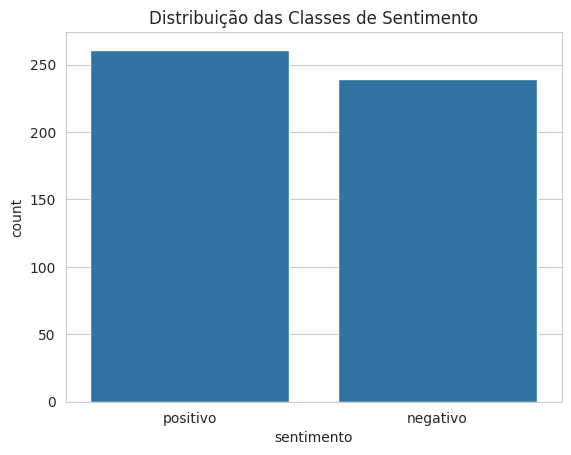

In [21]:
'''
  Proporção de classe - identificar se o resultado do valores está balanceado, ou seja,
  não estão distantes.
'''
print("\nDistribuição dos Sentimentos:\n")
sns.countplot(x = 'sentimento', data = df)
plt.title('Distribuição das Classes de Sentimento')
plt.show()

## 5. Limpeza de Dados
Realizar a limpeza e tratar valores ausentes - removendo, por exemplo, linhas correspondentes - para garantir que os dados estejam no formato correto.

In [22]:
# Remover linhas com valores ausentes (null)
print(f"\nTamanho original do DataFrame: {len(df)}")
df.dropna(subset = ['texto_review'], inplace = True)
print(f"Tamanho do DataFrame após remover nulos: {len(df)}")


Tamanho original do DataFrame: 500
Tamanho do DataFrame após remover nulos: 488


In [23]:
# Criar uma função para tratar os dados da coluna texto
def limpar_texto(texto):

    """
    Função completa de limpeza de texto:
    1. Remover os acentos e cedilhas.
    1. Converter todas as letras para minúsculas.
    3. Remover pontuações, números e caracteres especiais.
    4. Remover espaços extras.
    """

    # Garante que o texto não seja nulo (caso haja algum NaN no DataFrame)
    if not isinstance(texto, str):
        return ""

    # --- PASSO 1: Remover acentos ---
    # Normaliza para a forma 'NFKD' que separa o caractere da acentuação
    # e depois remove os acentos (Nonspacing Mark)
    texto_sem_acentos = ''.join(c for c in unicodedata.normalize('NFKD', texto) if unicodedata.category(c) != 'Mn')

    # --- PASSO 2: Limpeza com Regex ---
    # Converter para minúsculas
    texto_limpo = texto_sem_acentos.lower()

    # Manter apenas letras e espaços. A remoção de acentos já foi feita.
    texto_limpo = re.sub(r'[^a-z\s]', '', texto_limpo)

    # Remover espaços extras
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo).strip()

    return texto_limpo